In [14]:
#import all libraries in sequence of use
import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.model_selection import KFold, cross_val_score
import numpy as np 
import matplotlib.pyplot as plt

In [15]:
dataset=pd.read_csv("50_Startups.csv")

In [16]:
dataset

,R&D Spend,Administration,Marketing Spend,State,Profit
0,165349.20,136897.80,471784.10,New York,192261.83
1,162597.70,151377.59,443898.53,California,191792.06
2,153441.51,101145.55,407934.54,Florida,191050.39
3,144372.41,118671.85,383199.62,New York,182901.99
4,142107.34,91391.77,366168.42,Florida,166187.94
5,131876.90,99814.71,362861.36,New York,156991.12
6,134615.46,147198.87,127716.82,California,156122.51
7,130298.13,145530.06,323876.68,Florida,155752.60
8,120542.52,148718.95,311613.29,New York,152211.77
9,123334.88,108679.17,304981.62,California,149759.96


In [17]:
dataset=pd.get_dummies(dataset, drop_first=True, dtype=int)

In [18]:
dataset

,R&D Spend,Administration,Marketing Spend,Profit,State_Florida,State_New York
0,165349.20,136897.80,471784.10,192261.83,0,1
1,162597.70,151377.59,443898.53,191792.06,0,0
2,153441.51,101145.55,407934.54,191050.39,1,0
3,144372.41,118671.85,383199.62,182901.99,0,1
4,142107.34,91391.77,366168.42,166187.94,1,0
5,131876.90,99814.71,362861.36,156991.12,0,1
6,134615.46,147198.87,127716.82,156122.51,0,0
7,130298.13,145530.06,323876.68,155752.60,1,0
8,120542.52,148718.95,311613.29,152211.77,0,1
9,123334.88,108679.17,304981.62,149759.96,0,0


In [19]:
dataset.columns

Index(['R&D Spend', 'Administration', 'Marketing Spend', 'Profit',
       'State_Florida', 'State_New York'],
      dtype='object')

In [20]:
independent=dataset[['R&D Spend', 'Administration', 'Marketing Spend','State_Florida', 'State_New York']]

In [21]:
independent

,R&D Spend,Administration,Marketing Spend,State_Florida,State_New York
0,165349.20,136897.80,471784.10,0,1
1,162597.70,151377.59,443898.53,0,0
2,153441.51,101145.55,407934.54,1,0
3,144372.41,118671.85,383199.62,0,1
4,142107.34,91391.77,366168.42,1,0
5,131876.90,99814.71,362861.36,0,1
6,134615.46,147198.87,127716.82,0,0
7,130298.13,145530.06,323876.68,1,0
8,120542.52,148718.95,311613.29,0,1
9,123334.88,108679.17,304981.62,0,0


In [22]:
dependent=dataset['Profit']

In [23]:
regressor = Pipeline([
    ("scaler", StandardScaler()),
    ("svr", SVR(kernel="rbf", C=1000, gamma="scale", epsilon=1000))
])

In [24]:
kfold = KFold(
    n_splits=5,
    shuffle=True,
    random_state=0
)
scores = cross_val_score(
    regressor,            #StandardScaler() act here
    independent,          # With dataset feed here
    dependent,
    cv=kfold,             #with KFold Done
    scoring="r2"
)

In [25]:
print("="*60)
print("R2 Score for each fold:", scores)
print("Mean R2:", scores.mean())
print("Standard Deviation:", scores.std())
print("="*60)

R2 Score for each fold: [-0.08291912  0.02020542  0.15013613  0.03822834  0.09169836]
Mean R2: 0.04346982510031043
Standard Deviation: 0.07777732629284734


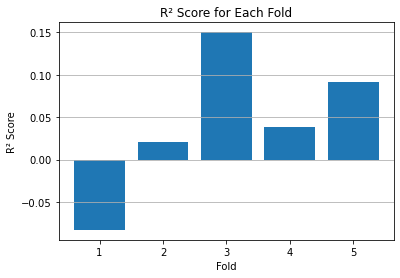

In [26]:
plt.close('all')

folds = np.arange(1, len(scores) + 1)

plt.figure(figsize=(6, 4))
plt.bar(folds, scores)

plt.xlabel("Fold")
plt.ylabel("R² Score")
plt.title("R² Score for Each Fold")
plt.xticks(folds)
plt.grid(axis='y')

plt.show()

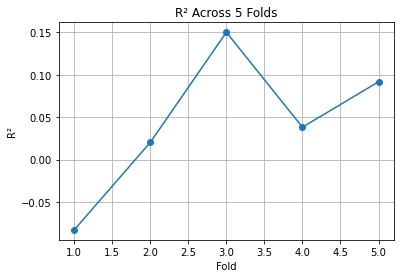

In [29]:
plt.plot(range(1,6), scores, marker='o')
plt.xlabel("Fold")
plt.ylabel("R²")
plt.title("R² Across 5 Folds")
plt.grid(True)
plt.show()

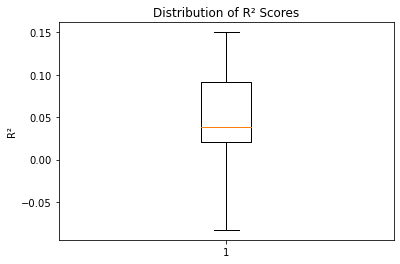

In [30]:
plt.boxplot(scores)
plt.ylabel("R²")
plt.title("Distribution of R² Scores")
plt.show()